In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, Image, display
import time
from abc import ABC, abstractmethod

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Dataset - 3D Ellipsoid Snowman

2 Ellipsoids with center on same line (intersection of x=a, y=b)

In [ ]:
def make_ellipsoid_snowman(n_points=2048, noise=0.01, min_center_x=-1, max_center_x=1, min_center_y=-1, max_center_y=1, min_center_z=0, max_center_z=3):
    # Create a snowman with two ellipsoids
    def ellipsoid(center, axes, n_points):
        phi = np.random.uniform(0, 2 * np.pi, n_points)
        costheta = np.random.uniform(-1, 1, n_points)
        u = np.random.uniform(0, 1, n_points)

        theta = np.arccos(costheta)
        r = u ** (1/3)

        x = center[0] + axes[0] * r * np.sin(theta) * np.cos(phi)
        y = center[1] + axes[1] * r * np.sin(theta) * np.sin(phi)
        z = center[2] + axes[2] * r * np.cos(theta)

        return x, y, z

    # Define the centers and axes of the three ellipsoids

    center_x = np.random.uniform(min_center_x, max_center_x)
    center_y = np.random.uniform(min_center_y, max_center_y)
    center_z1 = np.random.uniform(min_center_z, max_center_z)
    center_z2 = np.random.uniform(center_z1 + 0.5, max_center_z + 0.5)

    axes1 = np.random.uniform(0.5, 1.0, size=3)
    axes2 = np.random.uniform(0.3, 0.8, size=3)
    centers = [(center_x, center_y, center_z1), (center_x, center_y, center_z2)]
    axes = [axes1, axes2]

    points = []
    for center, axis in zip(centers, axes):
        x, y, z = ellipsoid(center, axis, n_points // len(centers))
        points.append(np.vstack((x, y, z)).T)

    snowman_points = np.vstack(points)
    snowman_points += noise * np.random.randn(*snowman_points.shape)  # Add noise
    return snowman_points

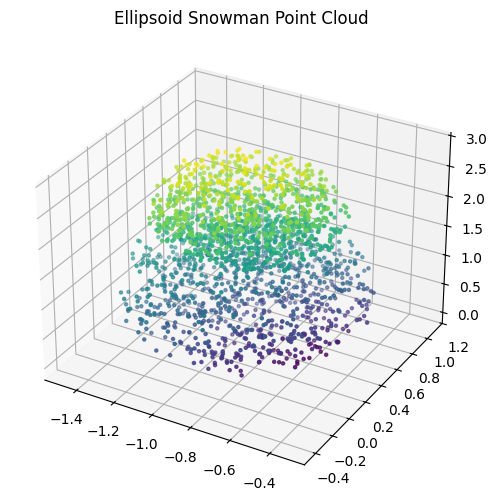

In [ ]:
pts = make_ellipsoid_snowman()
depth = np.linalg.norm(pts, axis=1)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=5, c=depth, cmap='viridis')
ax.set_title('Ellipsoid Snowman Point Cloud')
plt.show()

In [131]:
def generate_snowmans(n_snowmans=1000, n_points_per_snowman=2048):
    snowmans = []
    for _ in tqdm(range(n_snowmans), desc="Generating Snowmans"):
        snowman = make_ellipsoid_snowman(n_points=n_points_per_snowman)
        snowmans.append(snowman)
    return np.array(snowmans, dtype=np.float32)


def normalize_point_cloud_np(pc):
    # pc: (N, 3)
    center = np.mean(pc, axis=0, keepdims=True)
    pc = pc - center
    scale = np.max(np.linalg.norm(pc, axis=1))
    return pc / (scale + 1e-8)


def normalize_batch_point_clouds_np(batch_pc):
    # batch_pc: (B, N, 3)
    return np.stack([normalize_point_cloud_np(pc) for pc in batch_pc], axis=0).astype(np.float32)

In [132]:
snowmans = generate_snowmans(n_snowmans=1000, n_points_per_snowman=2048)
snowmans = normalize_batch_point_clouds_np(snowmans)  # sample-wise center/scale normalization

snowmans_t = torch.from_numpy(snowmans).float()
trainset = torch.utils.data.TensorDataset(snowmans_t, snowmans_t)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, drop_last=True)

Generating Snowmans: 100%|██████████| 1000/1000 [00:01<00:00, 872.63it/s]


In [106]:
print(len(trainset))
print(len(trainloader))
print(trainset[0][0].shape)

1000
16
torch.Size([2048, 3])


## PointNet Autoencoder: without KL term, vanilla AE

### PointNet Encoder

In [ ]:
class STNKd(nn.Module):
    # Spatial Transformer Network, a.k.a. T-Net for point clouds
    def __init__(self, k):
        super().__init__()
        self.k = k
        self.conv1 = nn.Sequential(nn.Conv1d(k, 64, 1), nn.BatchNorm1d(64))
        self.conv2 = nn.Sequential(nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128))
        self.conv3 = nn.Sequential(nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024))

        self.fc = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, k * k)
        )
    
    def forward(self, x):
        # Input: (B, k, N)
        # Output: (B, k, k)
        batch_size = x.size(0)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = torch.max(x, 2)[0]  # (B, 1024)
        x = self.fc(x)  # (B, k*k)

        identity = Variable(torch.eye(self.k, device=x.device).view(1, self.k * self.k).repeat(batch_size, 1))

        x = x + identity  # Initialize as identity
        x = x.view(-1, self.k, self.k)  # (B, k, k)
        return x

In [ ]:
class PointNetEncoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.input_transform = STNKd(3)
        self.conv1 = nn.Sequential(nn.Conv1d(3, 64, 1), nn.BatchNorm1d(64))
        self.feature_transform = STNKd(64)
        self.conv2 = nn.Sequential(nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128))
        self.conv3 = nn.Sequential(nn.Conv1d(128, 1024, 1), nn.BatchNorm1d(1024))

        self.fc = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

    def forward(self, x):
        # Input: (B, N, 3)
        # Output: (B, latent_dim)
        t3 = self.input_transform(x.transpose(1, 2))  # (B, 3, 3)
        x = torch.bmm(x, t3)  # (B, N, 3)
        x = F.relu(self.conv1(x.transpose(1, 2)))  # (B, 64, N)

        t64 = self.feature_transform(x)  # (B, 64, 64)
        x = torch.bmm(x.transpose(1, 2), t64).transpose(1, 2)  # (B, 64, N)
        x = F.relu(self.conv2(x))  # (B, 128, N)
        x = F.relu(self.conv3(x))  # (B, 1024, N)
        x = torch.max(x, 2)[0]  # (B, 1024)
        x = self.fc(x)  # (B, latent_dim)

        return x, t3, t64 # should regularize t3, t64 to orthogonal matrices

In [ ]:
def orthogonal_regularization(t, reg_weight=1e-3):
    # t: (B, k, k)
    batch_size, k, _ = t.size()
    identity = torch.eye(k, device=t.device).unsqueeze(0).repeat(batch_size, 1, 1)  # (B, k, k)
    t_transpose = t.transpose(1, 2)  # (B, k, k)
    product = torch.bmm(t, t_transpose)  # (B, k, k)

    mat_diff = (identity - product).reshape(batch_size, -1)  # (B, k*k)
    return reg_weight * torch.mean(torch.norm(mat_diff, dim=1))

In [ ]:
test_encoder = PointNetEncoder(latent_dim=64).to(device)
test_input = torch.randn(2, 2048, 3).to(device)
test_output, t3, t64 = test_encoder(test_input)
print("Output shape:", test_output.shape)
print("t3 shape:", t3.shape)
print("t64 shape:", t64.shape)
print("Orthogonal reg t3:", orthogonal_regularization(t3).item())
print("Orthogonal reg t64:", orthogonal_regularization(t64).item())

Output shape: torch.Size([2, 64])
t3 shape: torch.Size([2, 3, 3])
t64 shape: torch.Size([2, 64, 64])
Orthogonal reg t3: 0.003077829722315073
Orthogonal reg t64: 0.12475040555000305


### Point Cloud Decoder

In [133]:
class PointDecoder(nn.Module):
    def __init__(self, latent_dim=64, n_points=2048):
        super().__init__()
        self.n_points = n_points

        self.fc_in = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU()
        )

        self.fc_res1 = nn.Sequential(
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024)
        )

        self.fc_res2 = nn.Sequential(
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024)
        )

        self.fc_out = nn.Sequential(
            nn.ReLU(),
            nn.Linear(1024, n_points * 3),
            nn.Tanh()  # normalized output range
        )

    def forward(self, x):
        # Input: (B, latent_dim)
        # Output: (B, N, 3)
        x = self.fc_in(x)
        x = x + self.fc_res1(x)
        x = x + self.fc_res2(x)
        x = self.fc_out(x)
        x = x.view(-1, self.n_points, 3)
        return x

In [134]:
test_decoder = PointDecoder(latent_dim=64, n_points=2048).to(device)
test_latent = torch.randn(2, 64).to(device)
test_decoded = test_decoder(test_latent)
print("Decoded shape:", test_decoded.shape)

Decoded shape: torch.Size([2, 2048, 3])


### PointNet Autoencoder

In [137]:
def chamfer_distance(points1, points2):
    # points1, points2: (B, N, 3)
    dist = torch.cdist(points1, points2, p=2) ** 2  # squared euclidean
    cd1 = torch.min(dist, dim=2)[0].mean(dim=1)
    cd2 = torch.min(dist, dim=1)[0].mean(dim=1)
    return (cd1 + cd2).mean()

In [ ]:
class AEInterface(nn.Module, ABC):
    """Common interface for Autoencoders / Variational Autoencoders."""
    def __init__(self):
        super().__init__()

    @abstractmethod
    def encode(self, x):
        # Returns latent representation (or tuple/dict for VAE variants)
        raise NotImplementedError

    @abstractmethod
    def decode(self, latent):
        # Decodes latent to point cloud
        raise NotImplementedError

    @abstractmethod
    def reconstruct(self, x):
        # End-to-end reconstruction only
        raise NotImplementedError

    @abstractmethod
    def loss_forward(self, x, **kwargs):
        # Computes training loss (e.g., CD + regularizers [+ KL for VAE])
        raise NotImplementedError

    def forward(self, x):
        # Keep forward behavior consistent for inference/visualization
        return self.reconstruct(x)

In [ ]:
class PointCloudAutoencoder(AEInterface):
    def __init__(self, latent_dim=64, n_points=2048, reg_weight=1e-3):
        super().__init__()
        self.encoder = PointNetEncoder(latent_dim=latent_dim)
        self.decoder = PointDecoder(latent_dim=latent_dim, n_points=n_points)
        self.reg_weight = reg_weight

    def encode(self, x):
        latent, _, _ = self.encoder(x)
        return latent

    def decode(self, latent):
        return self.decoder(latent)

    def reconstruct(self, x):
        latent, _, _ = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed

    def forward_with_aux(self, x):
        # Optional: expose transform matrices for regularization/debugging
        latent, t3, t64 = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, t3, t64

    def loss_forward(self, x):
        reconstructed, t3, t64 = self.forward_with_aux(x)
        cd_loss = chamfer_distance(reconstructed, x)
        ortho_loss = orthogonal_regularization(t3, reg_weight=self.reg_weight) + orthogonal_regularization(t64, reg_weight=self.reg_weight)
        return cd_loss + ortho_loss

In [ ]:
def train_PAE(pae, dataloader, n_epochs=120, lr=3e-4, weight_decay=1e-4):
    pae.train()

    optimizer = optim.AdamW(
        list(pae.parameters()),
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-5)

    losses = []
    for epoch in range(n_epochs):
        total_loss = 0.0
        for batch_idx, (data, _) in enumerate(dataloader):
            data = data.to(device).float()  # (B, N, 3)
            optimizer.zero_grad()

            loss = pae.loss_forward(data, reg_weight=1e-3)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list(pae.parameters()), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()
        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.6f}, LR: {current_lr:.6e}")

    return losses

Epoch 1/120, Loss: 0.109850, LR: 2.999503e-04
Epoch 2/120, Loss: 0.024240, LR: 2.998013e-04
Epoch 3/120, Loss: 0.015983, LR: 2.995530e-04
Epoch 4/120, Loss: 0.013389, LR: 2.992057e-04
Epoch 5/120, Loss: 0.011744, LR: 2.987595e-04
Epoch 6/120, Loss: 0.010887, LR: 2.982148e-04
Epoch 7/120, Loss: 0.010196, LR: 2.975720e-04
Epoch 8/120, Loss: 0.009809, LR: 2.968314e-04
Epoch 9/120, Loss: 0.009593, LR: 2.959936e-04
Epoch 10/120, Loss: 0.008805, LR: 2.950592e-04
Epoch 11/120, Loss: 0.008567, LR: 2.940289e-04
Epoch 12/120, Loss: 0.008127, LR: 2.929032e-04
Epoch 13/120, Loss: 0.007958, LR: 2.916830e-04
Epoch 14/120, Loss: 0.008452, LR: 2.903692e-04
Epoch 15/120, Loss: 0.007578, LR: 2.889625e-04
Epoch 16/120, Loss: 0.006967, LR: 2.874641e-04
Epoch 17/120, Loss: 0.007405, LR: 2.858749e-04
Epoch 18/120, Loss: 0.007156, LR: 2.841959e-04
Epoch 19/120, Loss: 0.006831, LR: 2.824285e-04
Epoch 20/120, Loss: 0.006513, LR: 2.805737e-04
Epoch 21/120, Loss: 0.006238, LR: 2.786328e-04
Epoch 22/120, Loss: 0.

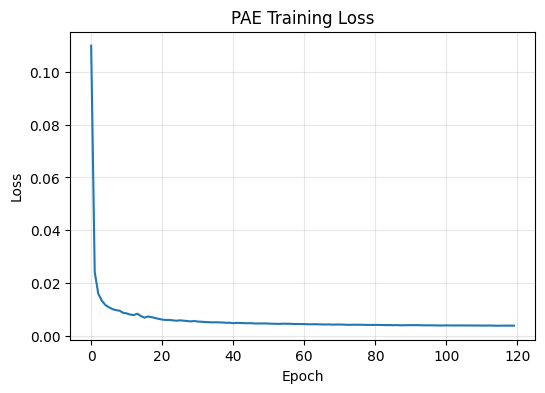

In [ ]:
ldim = 64
PAE = PointCloudAutoencoder(latent_dim=ldim, n_points=2048).to(device)

losses = train_PAE(PAE, trainloader, n_epochs=120, lr=3e-4, weight_decay=1e-4)

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("PAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def reconstruct_and_visualize(AE, data):
    AE.eval()
    with torch.no_grad():
        data = data.to(device).float().unsqueeze(0)  # (1, N, 3)
        reconstructed = AE.reconstruct(data).squeeze(0).cpu().numpy()  # (N, 3)

    original = data.squeeze(0).cpu().numpy()

    fig = plt.figure(figsize=(12, 6))
    ax1 = fig.add_subplot(121, projection='3d')
    depth = np.linalg.norm(original, axis=1)
    ax1.scatter(original[:, 0], original[:, 1], original[:, 2], s=5, c=depth, cmap='viridis')
    ax1.set_title('Original Point Cloud')

    ax2 = fig.add_subplot(122, projection='3d')
    depth_recon = np.linalg.norm(reconstructed, axis=1)
    ax2.scatter(reconstructed[:, 0], reconstructed[:, 1], reconstructed[:, 2], s=5, c=depth_recon, cmap='viridis')
    ax2.set_title('Reconstructed Point Cloud')
    plt.show()

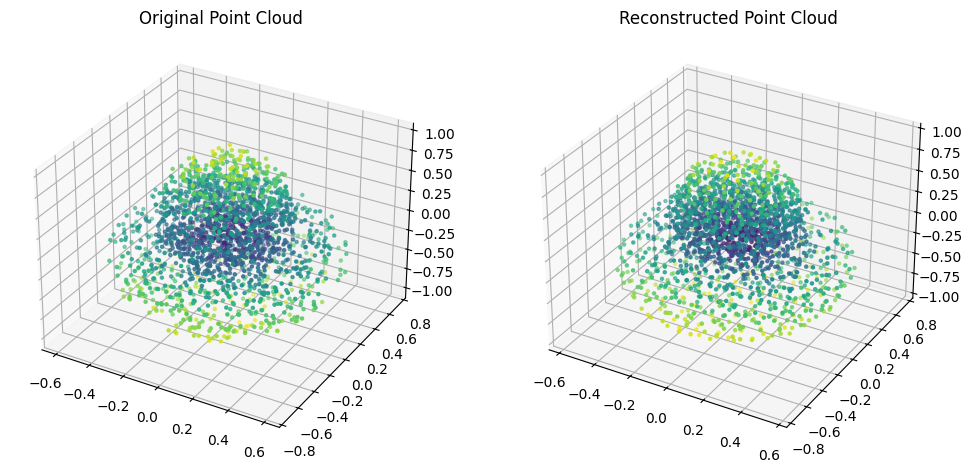

In [ ]:
reconstruct_and_visualize(PAE, torch.tensor(normalize_point_cloud_np(make_ellipsoid_snowman())))

In [ ]:
def latent_interpolation(AE, latent_dim_idx=0, input_latent = None, min=-1.0, max=1.0, steps=10):
    AE.eval()
    with torch.no_grad():
        latent_vectors = []
        for alpha in np.linspace(min, max, steps):
            if input_latent is not None:
                latent = input_latent.clone()
            else:
                latent = torch.zeros(1, AE.decoder.fc_in[0].in_features).to(device)
            latent[0, latent_dim_idx] = alpha
            latent_vectors.append(latent)

        latent_vectors = torch.cat(latent_vectors, dim=0)  # (steps, latent_dim)
        reconstructed_points = AE.decode(latent_vectors)  # (steps, N, 3)

    fig = plt.figure(figsize=(12, 6))
    for i in range(steps):
        ax = fig.add_subplot(2, steps//2, i+1, projection='3d')
        depth = np.linalg.norm(reconstructed_points[i].cpu().numpy(), axis=1)
        ax.scatter(reconstructed_points[i][:, 0].cpu(), reconstructed_points[i][:, 1].cpu(), reconstructed_points[i][:, 2].cpu(), s=5, c=depth, cmap='viridis')
        ax.set_title(f'Alpha: {np.linspace(min, max, steps)[i]:.2f}')
    plt.tight_layout()
    plt.show()

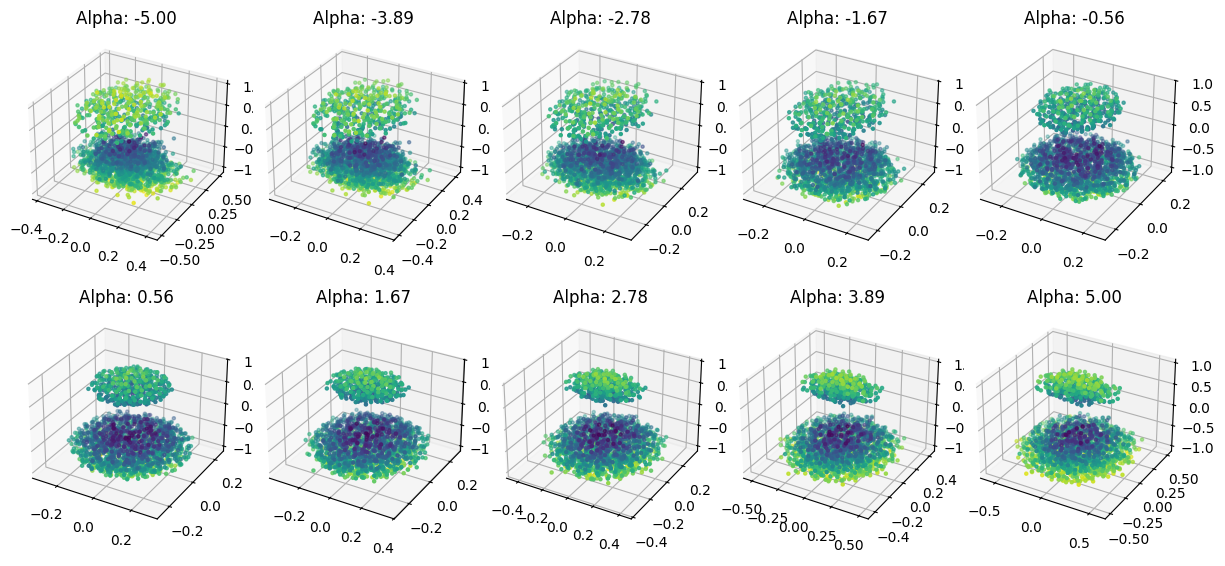

In [ ]:
latent = PAE.encode(torch.tensor(snowmans[0]).to(device).float().unsqueeze(0))[0]
idx = 5
print(latent[idx].item())
latent_interpolation(PAE, latent_dim_idx=idx, input_latent=latent, min=-5.0, max=5.0, steps=10)